### Cambio en las abundancias con acreción

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import PBHBeta.functions as fn_orig
import functionsaccret as fn_new
from PBHBeta import constants
from PBHBeta import constraints

Generando arreglo de masas desde 1g...
Calculando DM original (SBB)...


/home/javibiss/myenv/lib/python3.14/site-packages/PBHBeta/functions.py:86: RuntimeWarning: invalid value encountered in scalar power
  Om_0 = beta0 * b * (1. - time / Delta_t) ** (1. / 3)


Vectorizando integraciones de acreción...
Calculando DM con Acreción (Campo Escalar)...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionsaccret.py:212: RuntimeWarning: invalid value encountered in scalar power
  Om_0   = beta0 * b * (1. - time / Delta_t)**(1./3)


Graficando restricción de DM...


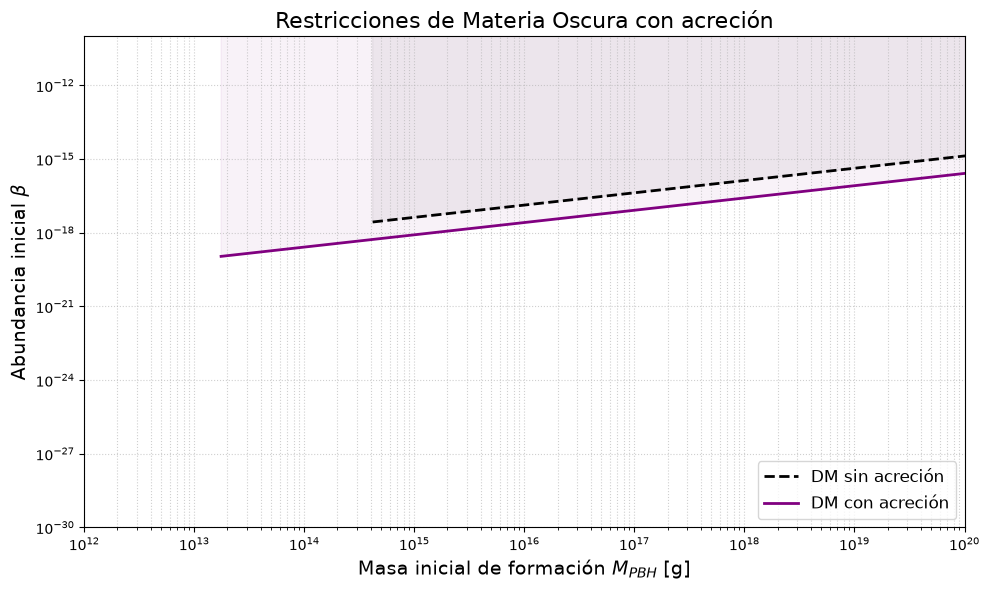

In [2]:
def comparar_solo_DM():
    print("Generando arreglo de masas desde 1g...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0/3.0 # Radiación después del Reheating
    N_fin = 55
    a_star = 0.9
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("Calculando DM original (SBB)...")
    from PBHBeta import constraints
    constraints.betas_DM_tot = [] # Limpiamos la memoria
    
    fn_orig.Betas_DM(M_tot, omega)
    betas_dm_orig = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (TU MODELO)
    # ---------------------------------------------------------
    print("Vectorizando integraciones de acreción...")
    constraints.betas_DM_tot = [] # Limpiamos de nuevo
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("Calculando DM con Acreción (Campo Escalar)...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    betas_dm_new = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    # PBHBeta usa valores "dummy" enormes (como 1e-5) cuando el PBH no es DM.
    # Filtramos cualquier valor mayor a 1e-10 convirtiéndolo en 'nan' para que desaparezca.
    betas_orig_clean = np.where(betas_dm_orig > 1e-10, np.nan, betas_dm_orig)
    betas_new_clean = np.where(betas_dm_new > 1e-10, np.nan, betas_dm_new)
    
    print("Graficando restricción de DM...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(M_tot, betas_orig_clean, label="DM sin acreción", color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="DM con acreción", color="purple", lw=2)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial $\beta$', fontsize=14)
    plt.title('Restricciones de Materia Oscura con acreción', fontsize=16)
    
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.1)
    plt.fill_between(M_tot, betas_new_clean, 1, color='purple', alpha=0.05)
    
    # Rango donde habitan los PBH de Materia Oscura
    plt.ylim(1e-30, 1e-10)
    plt.xlim(1e12, 1e20) 
    
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, which="both", ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_solo_DM()

In [ ]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_efolds_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star = 0.9
    N_efolds_list = [53, 54, 55, 55.1]
    
    # Colores diferenciados para cada N_efolds
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE E-FOLDS
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de E-folds...")
    for idx, N_fin in enumerate(N_efolds_list):
        print(f"   -> Procesando N_fin = {N_fin}...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), a_star)
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_new.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Graficación de la envolvente con acreción para el N_fin actual
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($N_{{efolds}} = {N_fin}$)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según la duración del Reheating ($a_*={a_star}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_efolds_restricciones()

1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo de E-folds...
   -> Procesando N_fin = 53...


1/5 - Generando arreglo cósmico de masas...
2/5 - Calculando las 7 restricciones del Modelo Estándar...


/home/javibiss/myenv/lib/python3.14/site-packages/PBHBeta/functions.py:86: RuntimeWarning: invalid value encountered in scalar power
  Om_0 = beta0 * b * (1. - time / Delta_t) ** (1. / 3)


3/5 - Acelerador JAX: Precalculando acreción para todo el universo...
4/5 - Evaluando las 7 restricciones con el modelo de Acreción...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionsaccret.py:212: RuntimeWarning: invalid value encountered in scalar power
  Om_0   = beta0 * b * (1. - time / Delta_t)**(1./3)


5/5 - Procesando gráfica final...
¡Listo! Mostrando gráfica...


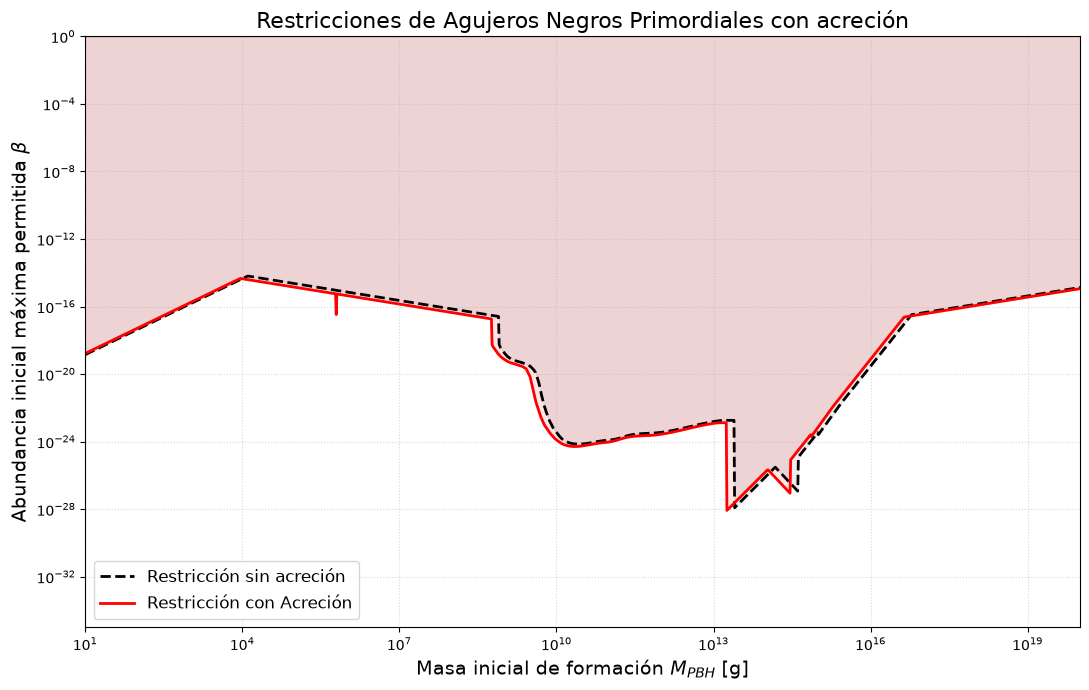

In [3]:

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_todas_las_restricciones():
    print("1/5 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    
    # Época de Reheating dominada por materia
    omega = 1.0/3.0 
    N_fin = 55
    a_star = 0.9
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/5 - Calculando las 7 restricciones del Modelo Estándar...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    # Obtenemos la envolvente total (la restricción más fuerte)
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/5 - Acelerador JAX: Precalculando acreción para todo el universo...")
    limpiar_memoria()
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("4/5 - Evaluando las 7 restricciones con el modelo de Acreción...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    
    # Obtenemos la envolvente total con acreción
    betas_new_full = fn_new.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    print("5/5 - Procesando gráfica final...")
    
    # Limpiamos los valores irreales para que matplotlib no dibuje líneas falsas
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
    
    plt.figure(figsize=(11, 7))
    
    plt.plot(M_tot, betas_orig_clean, label="Restricción sin acreción", 
             color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="Restricción con Acreción", 
             color="red", lw=2)
    
    # Sombreado para visualizar el espacio de parámetros prohibido
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, color='red', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(r'Restricciones de Agujeros Negros Primordiales con acreción($a={a_star},N = {N_fin}$)', fontsize=16)
    
    # Ajustamos la ventana para ver desde masas pequeñas hasta las gigantes
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    print("¡Listo! Mostrando gráfica...")
    plt.show()

if __name__ == "__main__":
    comparar_todas_las_restricciones()


1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo de E-folds...
   -> Procesando a_{*} = 0.0...
   -> Procesando a_{*} = 0.7...
   -> Procesando a_{*} = 0.9...
   -> Procesando a_{*} = 0.99...
4/4 - Renderizando gráfica final...


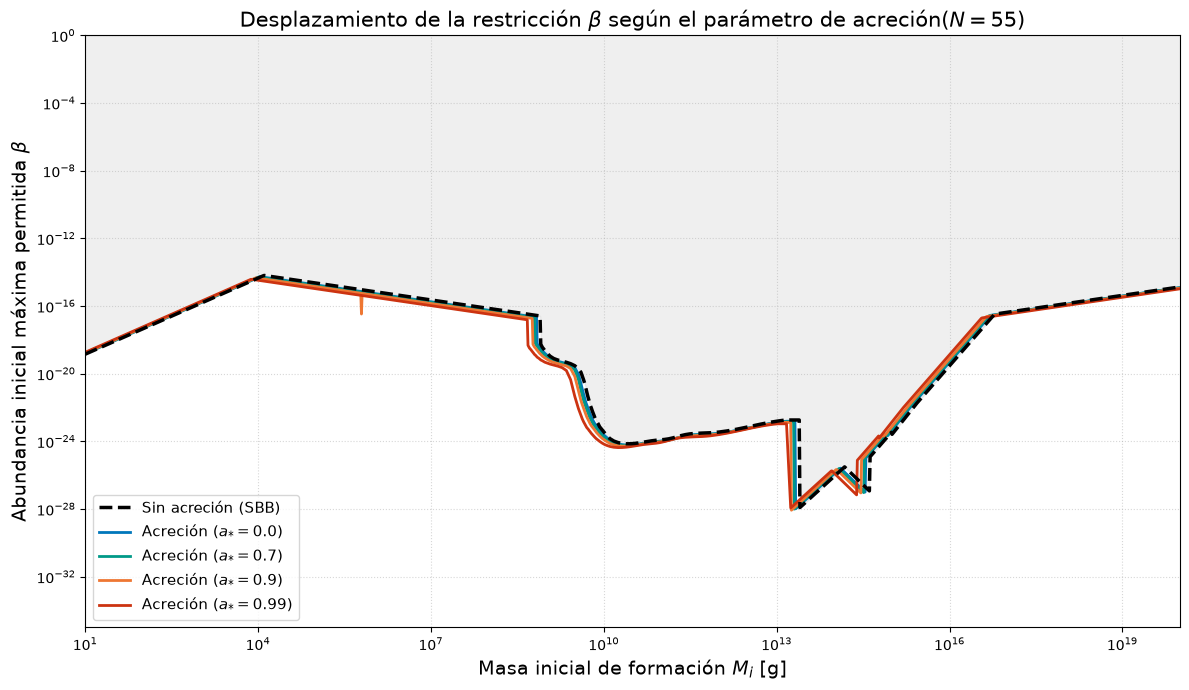

In [4]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_efolds_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star_list =[0.0, 0.7, 0.9, 0.99] 
    N_fin = 55
    
    # Colores diferenciados para cada N_efolds
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE E-FOLDS
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de E-folds...")
    for idx, a_star in enumerate(a_star_list):
        print(f"   -> Procesando a_{{*}} = {a_star}...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N_fin, float(a_star))
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_new.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Graficación de la envolvente con acreción para el N_fin actual
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($a_{{*}} = {a_star}$)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según el parámetro de acreción($N={N_fin}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_efolds_restricciones()

1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar...
3/4 - JAX: Calculando dinámica de acreción...
4/4 - Procesando gráfica comparativa...


/tmp/ipykernel_21057/462548711.py:119: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-35,0)


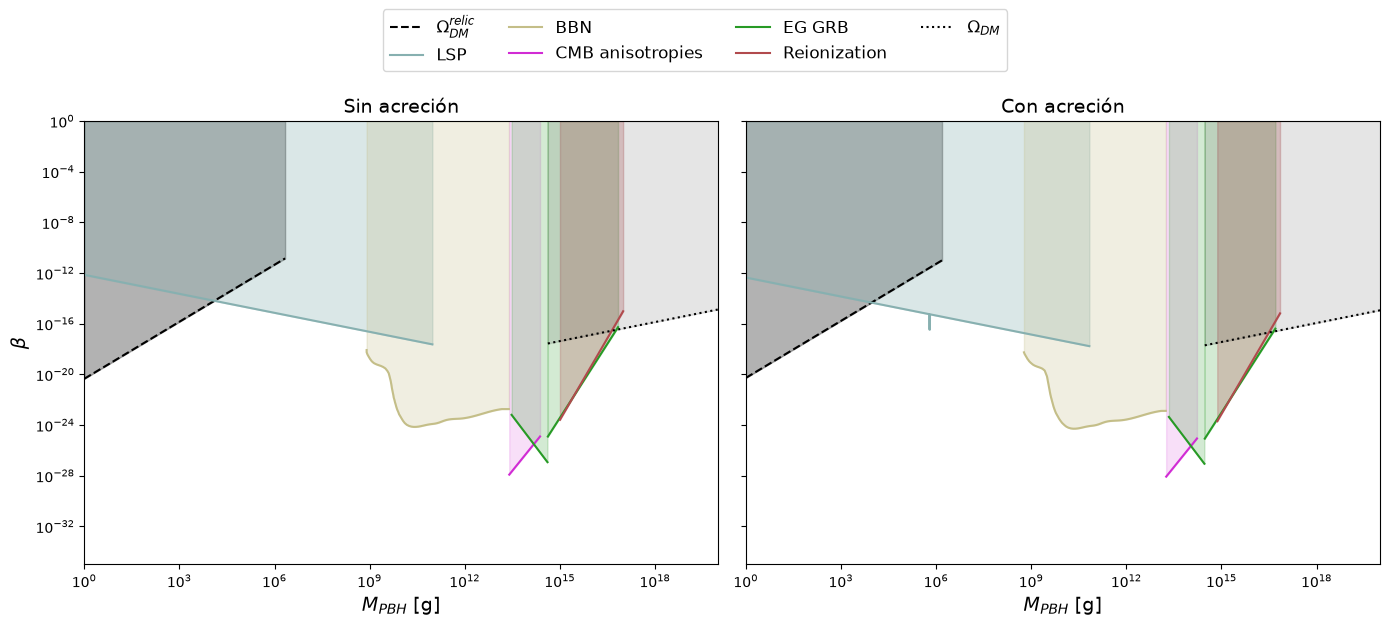

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Importamos las librerías
import PBHBeta.functions as fn_orig
import functionsaccret as fn_new
from PBHBeta import constants
from PBHBeta import constraints

def limpiar_memoria():
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0/3.0 # Reheating dominado por materia
    N = 55
    a = 0.9
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar...")
    limpiar_memoria()
    M_dm_n_std, betas_dm_n_std, M_relic_std, betas_relic_std, _ = fn_orig.Betas_DM(M_tot, omega)
    M_lsp_std, betas_lsp_std, _ = fn_orig.Betas_LSP(M_tot, omega)
    M_bbn_std, betas_bbn_std, _ = fn_orig.Betas_BBN(M_tot, omega)
    M_cmb_std, betas_cmb_std, _ = fn_orig.Betas_CMB_AN(M_tot, omega)
    M_grb1_std, M_grb2_std, betas_grb1_std, betas_grb2_std, _, _ = fn_orig.Betas_GRB(M_tot, omega)
    M_reio_std, betas_reio_std, _ = fn_orig.Betas_Reio(M_tot, omega)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción...")
    limpiar_memoria()
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp, N, a)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    M_dm_n_acc, betas_dm_n_acc, M_relic_acc, betas_relic_acc, _ = fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_lsp_acc, betas_lsp_acc, _ = fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_bbn_acc, betas_bbn_acc, _ = fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_cmb_acc, betas_cmb_acc, _ = fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_grb1_acc, M_grb2_acc, betas_grb1_acc, betas_grb2_acc, _, _ = fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_reio_acc, betas_reio_acc, _ = fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    
    # Creamos figura con 2 subplots que comparten el eje Y
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    # Función auxiliar para graficar en un eje específico (ax)
    def plot_y_sombrear(ax, x, y, color, label, linestyle='-', alpha_fill=0.3):
        if len(x) > 0:
            line, = ax.plot(x, y, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(x, y, 1.0, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("Sin acreción", fontsize=14)
    plot_y_sombrear(ax1, M_relic_std, betas_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, M_lsp_std, betas_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, M_bbn_std, betas_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_cmb_std, betas_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, M_grb1_std, betas_grb1_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_std) > 0:
        ax1.plot(M_grb2_std, betas_grb2_std, color=colores['grb'], lw=1.5)
        ax1.fill_between(M_grb2_std, betas_grb2_std, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax1, M_reio_std, betas_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_dm_n_std, betas_dm_n_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    ax2.set_title("Con acreción", fontsize=14)
    plot_y_sombrear(ax2, M_relic_acc, betas_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, M_lsp_acc, betas_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, M_bbn_acc, betas_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_cmb_acc, betas_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, M_grb1_acc, betas_grb1_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_acc) > 0:
        ax2.plot(M_grb2_acc, betas_grb2_acc, color=colores['grb'], lw=1.5)
        ax2.fill_between(M_grb2_acc, betas_grb2_acc, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax2, M_reio_acc, betas_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_dm_n_acc, betas_dm_n_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1e0, 1e20)
        ax.set_ylim(1e-30, 1e0)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL (Centrada arriba) ---
    # Extraemos las etiquetas de ax1 para no duplicarlas
    handles, labels = ax1.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=4, fontsize=12, frameon=True)
    plt.ylim(1e-35,0)
    plt.tight_layout()
    # Ajustamos para dejarle espacio a la leyenda global arriba
    fig.subplots_adjust(top=0.85) 
    
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()

### Cambio en las abundancias con acreción y evaporación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import PBHBeta.functions as fn_orig
import functionscompleto as fn_comp
from PBHBeta import constants
from PBHBeta import constraints


Generando arreglo de masas desde 1g...
Calculando DM original (SBB)...


/home/javibiss/myenv/lib/python3.14/site-packages/PBHBeta/functions.py:86: RuntimeWarning: invalid value encountered in scalar power
  Om_0 = beta0 * b * (1. - time / Delta_t) ** (1. / 3)


Vectorizando integraciones de acreción...
Calculando DM con Acreción y Evaporación...
Graficando restricción de DM...


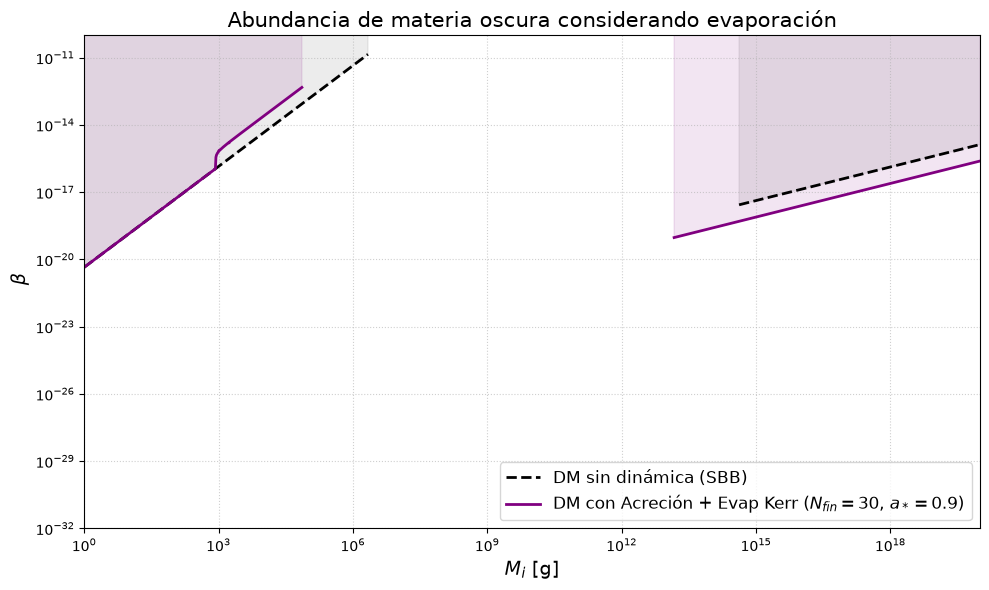

In [2]:
def comparar_solo_DM():
    print("Generando arreglo de masas desde 1g...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0 / 3.0  # Era de radiación (post-reheating)
    
    # Parámetros del modelo
    N_fin = 30.0
    a_star = 0.9
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("Calculando DM original (SBB)...")
    from PBHBeta import constraints
    constraints.betas_DM_tot = []  # Limpiamos la memoria
    
    fn_orig.Betas_DM(M_tot, omega)
    betas_dm_orig = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN Y EVAPORACIÓN (TU MODELO)
    # ---------------------------------------------------------
    print("Vectorizando integraciones de acreción...")
    constraints.betas_DM_tot = []  # Limpiamos la memoria de nuevo
    
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    # Precalculamos la acreción enviando N_fin y a_star
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), float(a_star))
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("Calculando DM con Acreción y Evaporación...")
    # CORRECCIÓN: Ya no enviamos a_star_f_tot, el modelo analítico no lo necesita
    fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    betas_dm_new = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    # Filtramos valores dummy (> 1e-10) a NaN para graficar únicamente regiones físicas
    betas_orig_clean = np.where(betas_dm_orig > 1e-10, np.nan, betas_dm_orig)
    betas_new_clean = np.where(betas_dm_new > 1e-10, np.nan, betas_dm_new)
    
    print("Graficando restricción de DM...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(M_tot, betas_orig_clean, label="DM sin dinámica (SBB)", color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label=f"DM con Acreción + Evap Kerr ($N_{{fin}}={int(N_fin)}$, $a_*={a_star}$)", color="purple", lw=2)
    
    # Mascaras seguras para el sombreado evitando NaNs
    mask_orig = ~np.isnan(betas_orig_clean)
    mask_new = ~np.isnan(betas_new_clean)
    
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, where=mask_new, color='purple', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$M_i$ [g]', fontsize=14)
    plt.ylabel(r' $\beta$', fontsize=14)
    plt.title('Abundancia de materia oscura considerando evaporación', fontsize=15)
  
    plt.ylim(1e-32, 1e-10)
    plt.xlim(1.0, 1e20) 
    
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, which="both", ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_solo_DM()

1/5 - Generando arreglo cósmico de masas...
2/5 - Calculando las 7 restricciones del Modelo Estándar...
3/5 - Acelerador JAX: Precalculando acreción para todo el universo...
4/5 - Evaluando las 7 restricciones con el modelo de Acreción...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscompleto.py:377: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)
/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscompleto.py:595: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)


5/5 - Procesando gráfica final...
¡Listo! Mostrando gráfica...


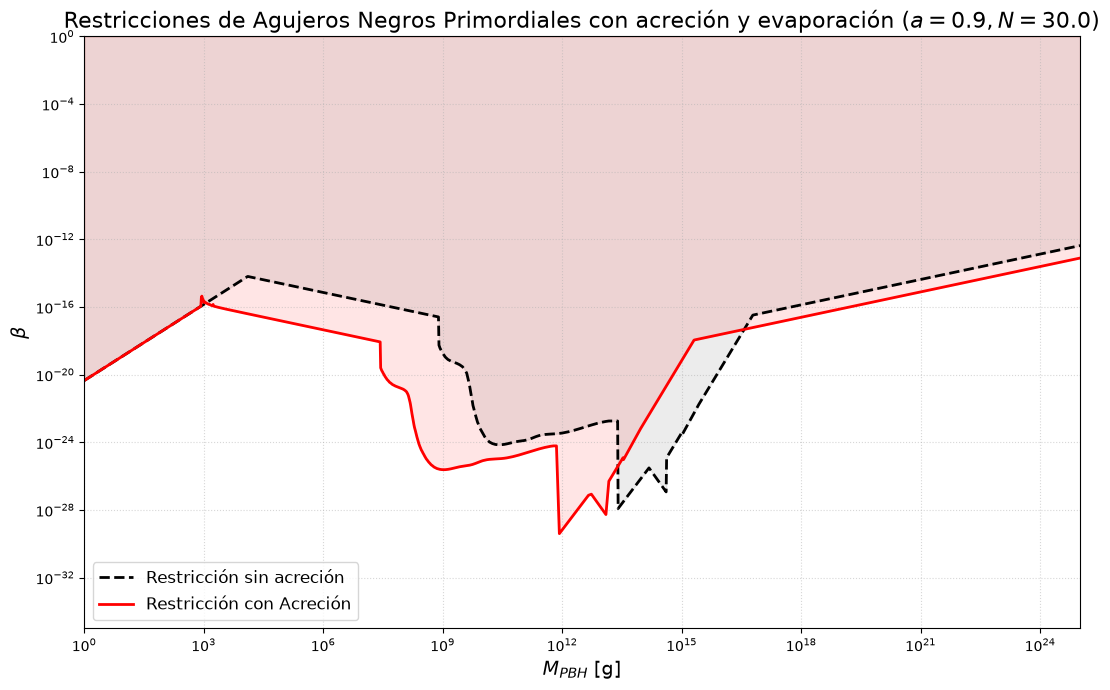

In [3]:

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_todas_las_restricciones():
    print("1/5 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e25)
    
    omega = 1.0/3.0 #Época dominada por radiación
    N_fin = 30.0
    a_star = 0.9
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/5 - Calculando las 7 restricciones del Modelo Estándar...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    # Obtenemos la envolvente total (la restricción más fuerte)
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/5 - Acelerador JAX: Precalculando acreción para todo el universo...")
    limpiar_memoria()
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("4/5 - Evaluando las 7 restricciones con el modelo de Acreción...")
    fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    
    # Obtenemos la envolvente total con acreción
    betas_new_full = fn_comp.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    print("5/5 - Procesando gráfica final...")
    
    # Limpiamos los valores irreales para que matplotlib no dibuje líneas falsas
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
    
    plt.figure(figsize=(11, 7))
    
    plt.plot(M_tot, betas_orig_clean, label="Restricción sin acreción", 
             color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="Restricción con Acreción", 
             color="red", lw=2)
    
    # Sombreado para visualizar el espacio de parámetros prohibido
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, color='red', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'$M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'$\beta$', fontsize=14)
    plt.title(f'Restricciones de Agujeros Negros Primordiales con acreción y evaporación ($a={a_star},N = {N_fin}$)', fontsize=16)
    
    # Ajustamos la ventana para ver desde masas pequeñas hasta las gigantes
    plt.ylim(1e-35, 1e0)
    plt.xlim(1.0, 1e25) 
    
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    print("¡Listo! Mostrando gráfica...")
    plt.show()

if __name__ == "__main__":
    comparar_todas_las_restricciones()

1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo de E-folds...
   -> Procesando a_{*} = 0.0...
   -> Procesando a_{*} = 0.7...
   -> Procesando a_{*} = 0.9...
   -> Procesando a_{*} = 0.99...
4/4 - Renderizando gráfica final...


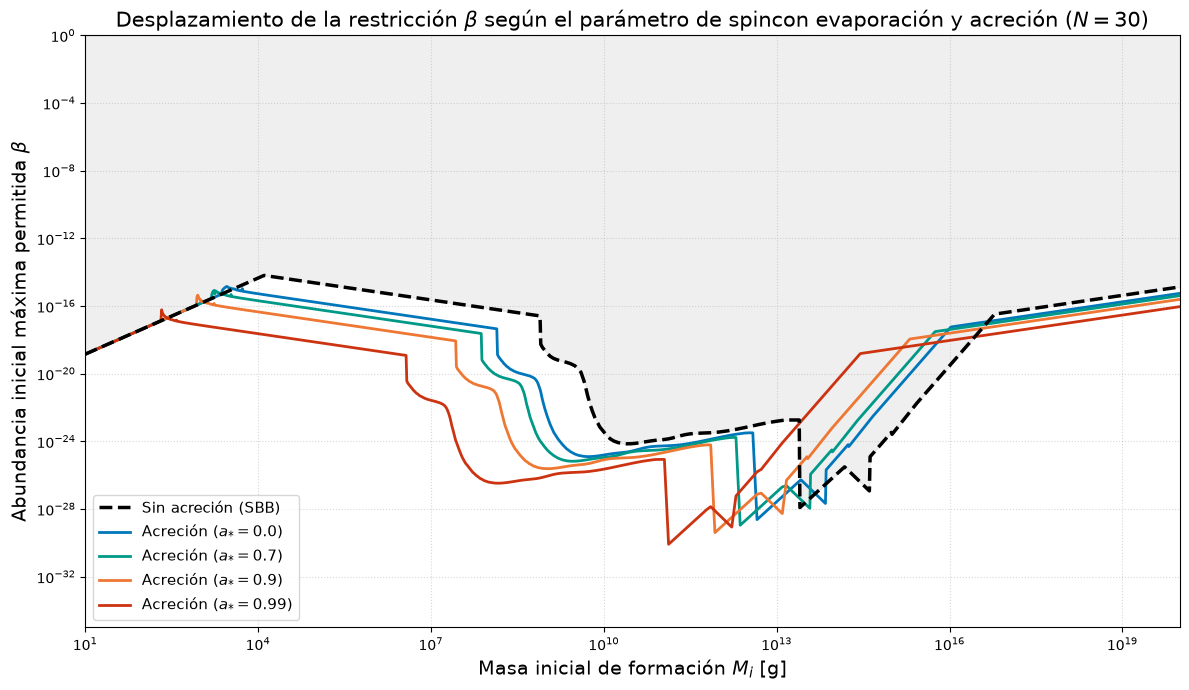

In [4]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_efolds_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star_list =[0.0, 0.7, 0.9, 0.99] 
    N_fin = 30
    
    # Colores diferenciados para cada N_efolds
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE E-FOLDS
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de E-folds...")
    for idx, a_star in enumerate(a_star_list):
        print(f"   -> Procesando a_{{*}} = {a_star}...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, float(a_star))
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_comp.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Graficación de la envolvente con acreción para el N_fin actual
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($a_{{*}} = {a_star}$)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según el parámetro de spincon evaporación y acreción ($N={N_fin}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_efolds_restricciones()


1/4 - Generando arreglo cósmico de masas...
2/4 - Calculando restricciones del Modelo Estándar (SBB)...
3/4 - Evaluando acreción para el arreglo de E-folds...
   -> Procesando N_fin = 28...
   -> Procesando N_fin = 29...
   -> Procesando N_fin = 30...
   -> Procesando N_fin = 31...
4/4 - Renderizando gráfica final...


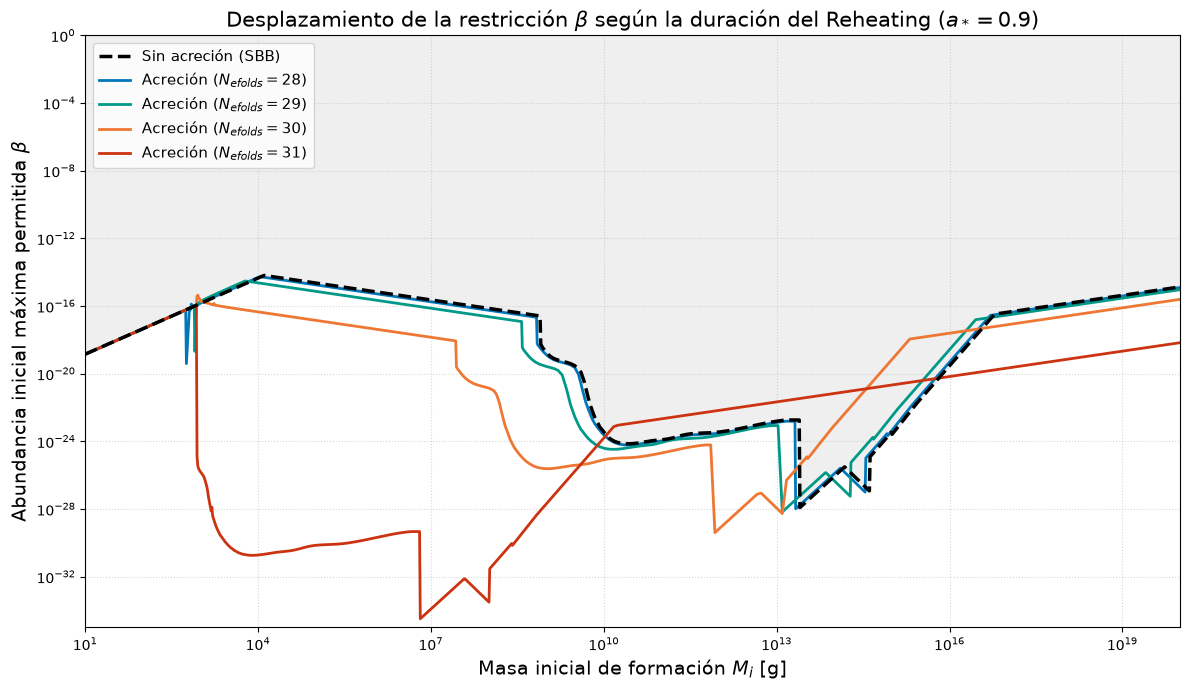

In [7]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_efolds_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star = 0.9
    N_efolds_list = [28, 29, 30, 31]
    
    # Colores diferenciados para cada N_efolds
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE E-FOLDS
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de E-folds...")
    for idx, N_fin in enumerate(N_efolds_list):
        print(f"   -> Procesando N_fin = {N_fin}...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), a_star)
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_comp.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Graficación de la envolvente con acreción para el N_fin actual
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($N_{{efolds}} = {N_fin}$)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según la duración del Reheating ($a_*={a_star}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_efolds_restricciones()

In [ ]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def calcular_N_re(T_re_GeV, omega):
    """
    Despeja analíticamente el número de e-folds (N_re) a partir de la temperatura 
    de recalentamiento (T_re) usando la Ec. 2.46 del modelo cosmológico.
    """
    # Constantes físicas fundamentales en GeV
    M_p = 2.435e18  # Masa de Planck reducida
    H_end_GeV = 4.44e13
    g_star = 106.75 # Grados de libertad relativistas al final de reheating
    
    # Densidad de energía al final de la inflación
    rho_end = 3.0 * (M_p**2) * (H_end_GeV**2)
    
    # Términos de la ecuación 2.46
    termino_constante = (30.0 / (np.pi**2 * g_star))**0.25
    rho_cuarto = rho_end**0.25
    
    # Despeje de N_re
    argumento_ln = termino_constante * (rho_cuarto / T_re_GeV)
    N_re = (4.0 / (3.0 * (1.0 + omega))) * np.log(argumento_ln)
    
    return N_re

def comparar_Tre_restricciones():
    print("1/4 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0 / 3.0 
    a_star = 0.9
    
    # Rango de temperaturas basado en la Fig. 10 del artículo (10^9.6 a 10^10.4 GeV)
    T_re_list = [10**9.6, 10**9.8, 10**10.0, 10**10.2, 10**10.4]
    
    # Paleta de colores secuencial para simular un mapa de calor similar a la gráfica original
    colores = ['#004488', '#228833', '#DDAA33', '#CC6677', '#AA4499']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB - Sin acreción)
    # ---------------------------------------------------------
    print("2/4 - Calculando restricciones del Modelo Estándar (SBB)...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO ITERATIVO PARA CADA VALOR DE TEMPERATURA
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # Graficar la curva base (SBB)
    plt.plot(M_tot, betas_orig_clean, label="Sin acreción (SBB)", 
             color="black", linestyle="--", lw=2.5, zorder=10)
    
    mask_orig = ~np.isnan(betas_orig_clean)
    plt.fill_between(M_tot, betas_orig_clean, 1, where=mask_orig, color='gray', alpha=0.12)
    
    print("3/4 - Evaluando acreción para el arreglo de Temperaturas...")
    for idx, T_re in enumerate(T_re_list):
        # Mapeo físico de T_re a N_fin
        N_fin = calcular_N_re(T_re, omega)
        
        print(f"   -> Procesando T_re = {T_re:.2e} GeV (equivale a N_fin = {N_fin:.2f})...")
        limpiar_memoria()
        
        # Precálculo vectorizado en JAX para el N_fin actual
        M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), a_star)
        M_f_tot = np.array(M_f_tot_jnp)
        mu_tot = np.array(mu_tot_jnp)
        
        # Evaluación de las 7 restricciones con acreción
        fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
        
        betas_new_full = fn_comp.get_Betas_full(M_tot)
        betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
        
        # Exponente en base 10 para una leyenda más limpia
        log_Tre = np.log10(T_re)
        
        # Graficación de la envolvente con acreción
        plt.plot(M_tot, betas_new_clean, 
                 label=f"Acreción ($T_{{re}} = 10^{{{log_Tre:.1f}}}$ GeV)", 
                 color=colores[idx], lw=2)
    
    # ---------------------------------------------------------
    # 3. FORMATO Y PRESENTACIÓN
    # ---------------------------------------------------------
    print("4/4 - Renderizando gráfica final...")
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title(f'Desplazamiento de la restricción $\\beta$ según Temperatura de Reheating ($a_*={a_star}$)', fontsize=15)
    
    # Ajuste de límites para capturar los desplazamientos hacia masas menores
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    comparar_Tre_restricciones()

In [6]:
#Esto no es una contradicción? es decir, Mientras mayor N, menor T_RH, entonces, los PBHs deben ser más 
#masivos, por ello, los constraints en PBHs de masas mayores deben permitir una mayor abundancia.

1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar...
3/4 - JAX: Calculando dinámica de acreción...
4/4 - Procesando gráfica comparativa...


/tmp/ipykernel_38707/2990001637.py:109: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-35,0)


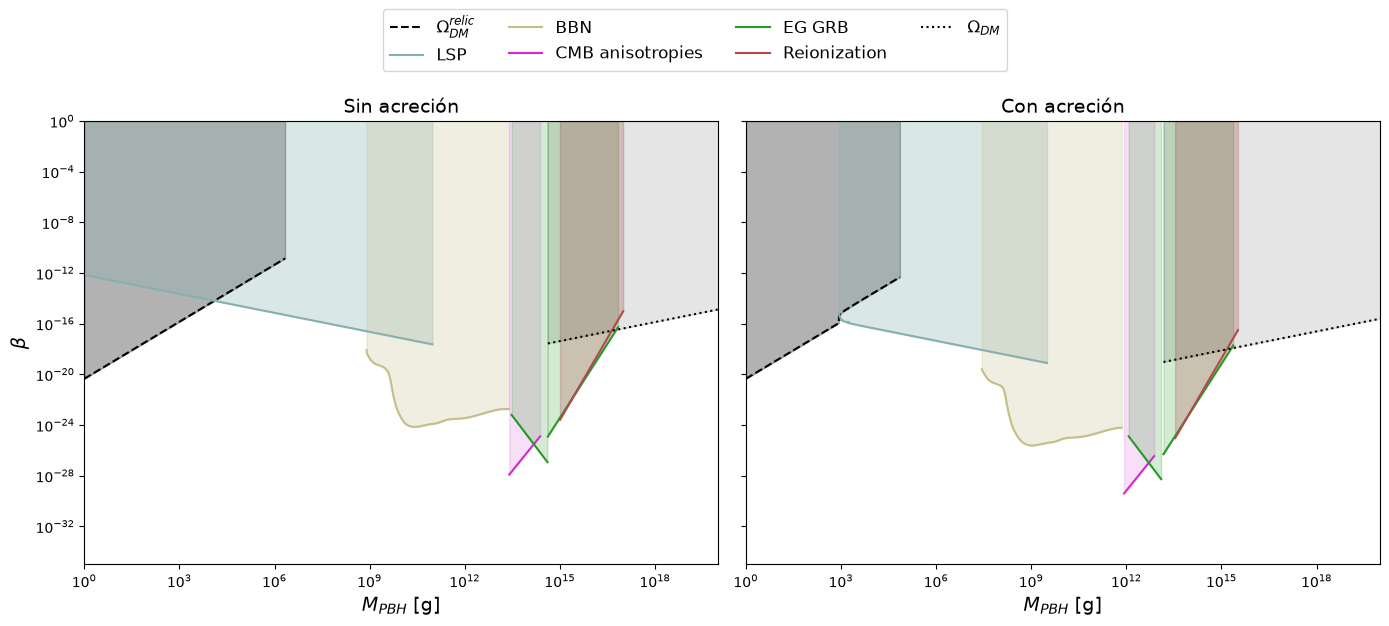

In [6]:

def limpiar_memoria():
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 1.0/3.0 # Reheating dominado por materia
    N = 30
    a = 0.9
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar...")
    limpiar_memoria()
    M_dm_n_std, betas_dm_n_std, M_relic_std, betas_relic_std, _ = fn_orig.Betas_DM(M_tot, omega)
    M_lsp_std, betas_lsp_std, _ = fn_orig.Betas_LSP(M_tot, omega)
    M_bbn_std, betas_bbn_std, _ = fn_orig.Betas_BBN(M_tot, omega)
    M_cmb_std, betas_cmb_std, _ = fn_orig.Betas_CMB_AN(M_tot, omega)
    M_grb1_std, M_grb2_std, betas_grb1_std, betas_grb2_std, _, _ = fn_orig.Betas_GRB(M_tot, omega)
    M_reio_std, betas_reio_std, _ = fn_orig.Betas_Reio(M_tot, omega)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción...")
    limpiar_memoria()
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N, a)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    M_dm_n_acc, betas_dm_n_acc, M_relic_acc, betas_relic_acc, _ = fn_comp.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_lsp_acc, betas_lsp_acc, _ = fn_comp.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_bbn_acc, betas_bbn_acc, _ = fn_comp.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_cmb_acc, betas_cmb_acc, _ = fn_comp.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_grb1_acc, M_grb2_acc, betas_grb1_acc, betas_grb2_acc, _, _ = fn_comp.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_reio_acc, betas_reio_acc, _ = fn_comp.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    
    # Creamos figura con 2 subplots que comparten el eje Y
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    # Función auxiliar para graficar en un eje específico (ax)
    def plot_y_sombrear(ax, x, y, color, label, linestyle='-', alpha_fill=0.3):
        if len(x) > 0:
            line, = ax.plot(x, y, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(x, y, 1.0, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("Sin acreción", fontsize=14)
    plot_y_sombrear(ax1, M_relic_std, betas_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, M_lsp_std, betas_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, M_bbn_std, betas_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_cmb_std, betas_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, M_grb1_std, betas_grb1_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_std) > 0:
        ax1.plot(M_grb2_std, betas_grb2_std, color=colores['grb'], lw=1.5)
        ax1.fill_between(M_grb2_std, betas_grb2_std, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax1, M_reio_std, betas_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_dm_n_std, betas_dm_n_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    ax2.set_title("Con acreción", fontsize=14)
    plot_y_sombrear(ax2, M_relic_acc, betas_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, M_lsp_acc, betas_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, M_bbn_acc, betas_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_cmb_acc, betas_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, M_grb1_acc, betas_grb1_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_acc) > 0:
        ax2.plot(M_grb2_acc, betas_grb2_acc, color=colores['grb'], lw=1.5)
        ax2.fill_between(M_grb2_acc, betas_grb2_acc, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax2, M_reio_acc, betas_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_dm_n_acc, betas_dm_n_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1e0, 1e20)
        ax.set_ylim(1e-30, 1e0)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL (Centrada arriba) ---
    # Extraemos las etiquetas de ax1 para no duplicarlas
    handles, labels = ax1.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=4, fontsize=12, frameon=True)
    plt.ylim(1e-35,0)
    plt.tight_layout()
    # Ajustamos para dejarle espacio a la leyenda global arriba
    fig.subplots_adjust(top=0.85) 
    
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()